<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/emerging_trends/blockchain_restructured_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trusted Certification System: From Smart Contracts to Blockchain
This notebook demonstrates trust: decision → record → verification → blockchain.

## Step 0: Problem Context
How do we ensure certificates are trusted and verifiable?

In [ ]:
!pip install reportlab pdf2image
!apt-get install -y poppler-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.4 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (623 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from pdf2image import convert_from_path
from IPython.display import display
from google.colab import files
import hashlib, datetime, json

## Step 1: Smart Contract

In [ ]:
class SmartContract:
    def __init__(self, student, course, score):
        self.student = student
        self.course = course
        self.score = score
        self.timestamp = str(datetime.datetime.now())
        self.status = None

    def evaluate(self):
        self.status = "APPROVED" if self.score >= 50 else "REJECTED"
        return self.status

    def get_record(self):
        return {
            "student": self.student,
            "course": self.course,
            "score": self.score,
            "status": self.status,
            "timestamp": self.timestamp
        }

contract = SmartContract("Student A","Blockchain Basics",70)
contract.evaluate()
record = contract.get_record()
record

{'student': 'Student A',
 'course': 'Blockchain Basics',
 'score': 70,
 'status': 'APPROVED',
 'timestamp': '2026-04-10 15:30:05.012512'}

## Step 2: Hashing

In [ ]:
def generate_hash(data):
    return hashlib.sha256(json.dumps(data).encode()).hexdigest()

hash_code = generate_hash(record)
hash_code

'b937d8529e4909673f8eb4156bc20275573c2dbfc2fbbec9217d150a06314559'

## Step 3: Certificate

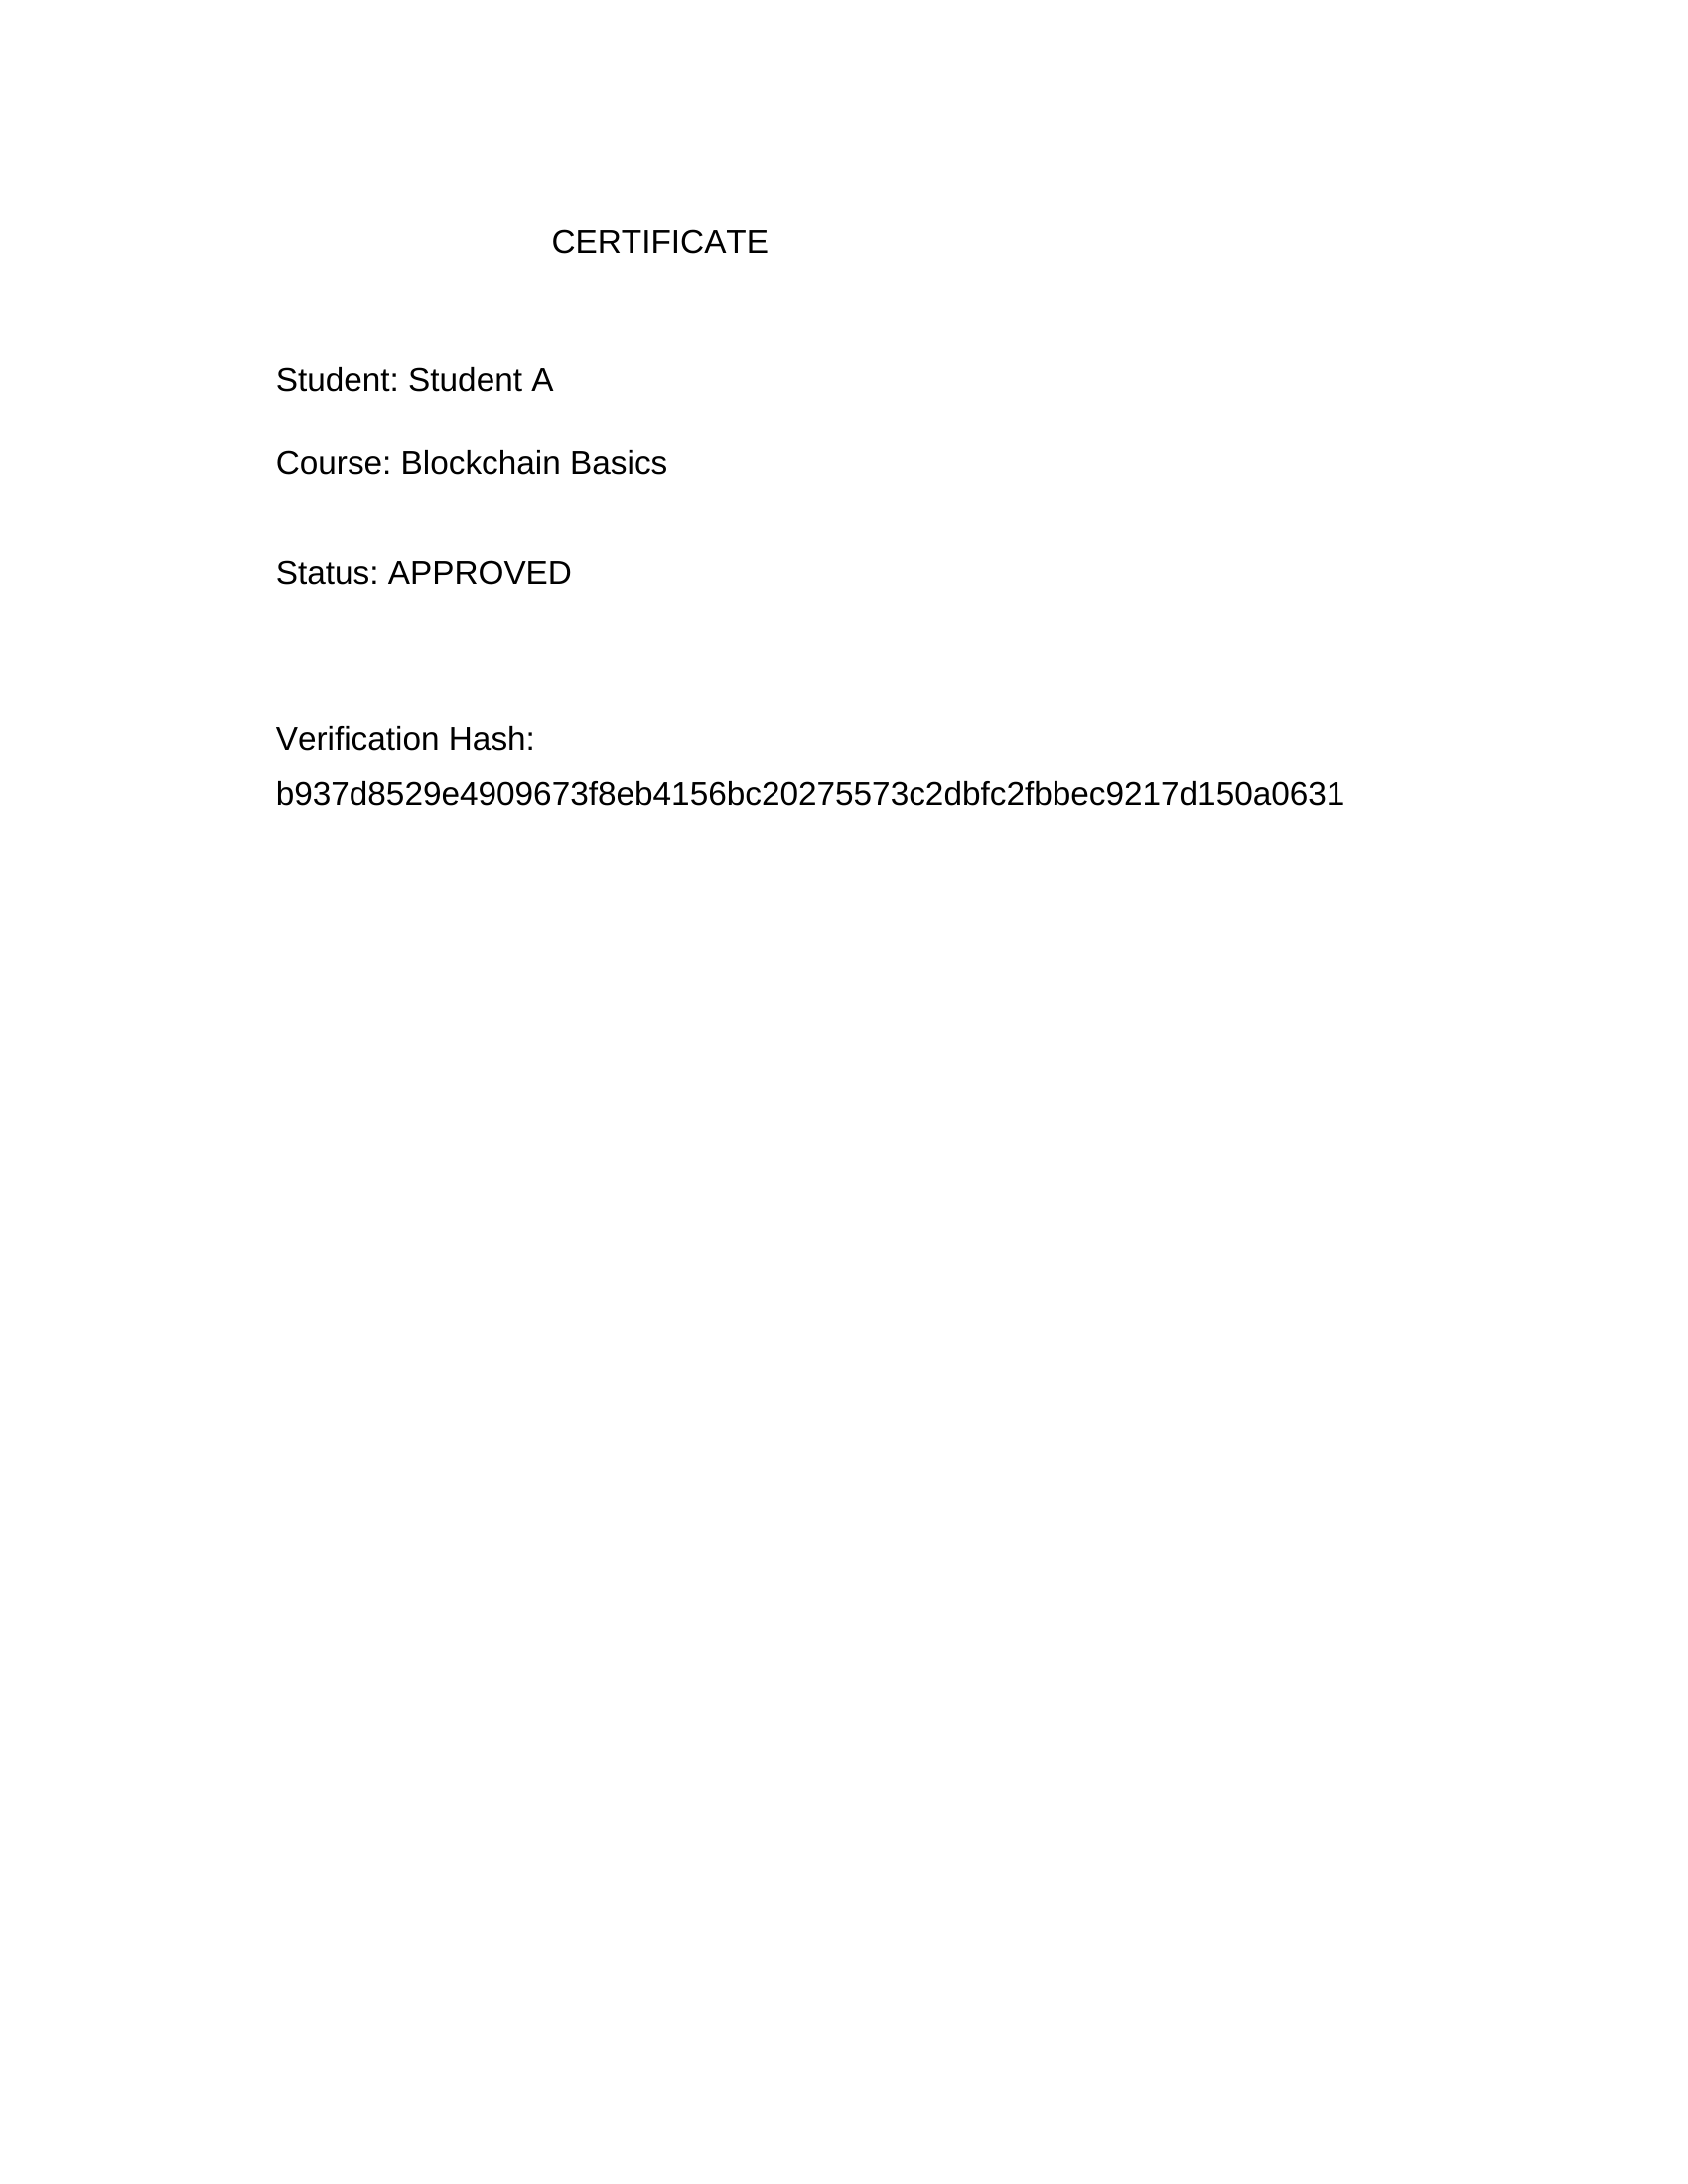

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def generate_certificate(student, course, status, hash_code):
    file = f"{student.replace(' ', '_')}_certificate.pdf"

    c = canvas.Canvas(file, pagesize=letter)
    c.drawString(200, 700, "CERTIFICATE")
    c.drawString(100, 650, f"Student: {student}")
    c.drawString(100, 620, f"Course: {course}")
    c.drawString(100, 580, f"Status: {status}")
    c.drawString(100, 520, "Verification Hash:")
    c.drawString(100, 500, hash_code[:60])
    c.save()

    images = convert_from_path(file)
    display(images[0])
    files.download(file)

if contract.status == "APPROVED":
    generate_certificate(contract.student, contract.course, contract.status, hash_code)

## Step 4: Verification

In [ ]:
def verify_certificate(record, original_hash):
    return generate_hash(record) == original_hash

verify_certificate(record, hash_code)

True

## Step 5: Blockchain

In [ ]:
class Block:
    def __init__(self, index, data, prev):
        self.index=index
        self.data=data
        self.prev=prev
        self.hash=self.calc()
    def calc(self):
        return hashlib.sha256(json.dumps(self.__dict__).encode()).hexdigest()

class Blockchain:
    def __init__(self):
        self.chain=[Block(0,{"genesis":True},"0")]
    def add(self,data):
        prev=self.chain[-1]
        self.chain.append(Block(len(self.chain),data,prev.hash))
    def show(self):
        for b in self.chain:
            print(b.index,b.data,b.hash)

chain = Blockchain()
chain.add(record)
chain.show()

0 {'genesis': True} 2c7c2170e8edbbbc15639c1da904880fa5ca0c39421b51a1b8b0d0581c65d165
1 {'student': 'Student A', 'course': 'Blockchain Basics', 'score': 70, 'status': 'APPROVED', 'timestamp': '2026-04-10 15:30:05.012512'} d5a063e6eece570659dc7f9f992797310cd31fe1aa55383e57d6053f74f3c162


## Step 6: Real Platforms
Try Remix (Ethereum) or Algorand for real deployment.